In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [20]:
url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/LifeExpectancy.csv"

df = pd.read_csv(url)

# Clean column names
df.columns = df.columns.str.strip()

df.head()

,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Life expectancy
0,1.75,491.497891,98.0,75,16.7,98.0,5.90,98.0,0.1,3432.247841,34.0,14.6,14.7,0.601,11.8,72.7
1,1.59,100.503021,98.0,6,21.2,98.0,9.22,98.0,0.1,597.165900,36.0,14.1,14.2,0.651,11.8,76.3
2,0.01,2051.748615,99.0,0,26.2,99.0,13.73,99.0,0.1,7716.241500,41.0,13.6,13.7,0.693,12.7,78.2
3,7.17,151.762567,89.0,56,5.5,9.0,8.99,92.0,0.1,3174.949100,43.0,2.6,2.8,0.735,13.1,73.9
4,10.78,19.220240,NaN,0,61.7,99.0,7.85,99.0,0.1,1325.533790,123.0,1.8,1.8,0.817,15.3,74.5


In [21]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (2938, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Alcohol                          2744 non-null   float64
 1   percentage expenditure           2938 non-null   float64
 2   Hepatitis B                      2385 non-null   float64
 3   Measles                          2938 non-null   int64  
 4   BMI                              2904 non-null   float64
 5   Polio                            2919 non-null   float64
 6   Total expenditure                2712 non-null   float64
 7   Diphtheria                       2919 non-null   float64
 8   HIV/AIDS                         2938 non-null   float64
 9   GDP                              2490 non-null   float64
 10  Population                       2286 non-null   float64
 11  thinness  1-19 years             2904 non-null   floa

In [22]:
missing = df.isnull().sum().sort_values(ascending=False)

print(missing)

Population                         652
Hepatitis B                        553
GDP                                448
Total expenditure                  226
Alcohol                            194
Income composition of resources    167
Schooling                          163
BMI                                 34
thinness 5-9 years                  34
thinness  1-19 years                34
Diphtheria                          19
Polio                               19
Life expectancy                     10
Measles                              0
percentage expenditure               0
HIV/AIDS                             0
dtype: int64


Several features contain missing values, especially GDP, Population, and Hepatitis B. This indicates the need for imputation before training machine learning models.

In [23]:
df.describe()

,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Life expectancy
count,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000,2928.000000
mean,4.602861,738.251295,80.940461,2419.592240,38.321247,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793,69.224932
std,4.052413,1987.914858,25.070016,11467.272489,20.044034,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920,9.523867
min,0.010000,0.000000,1.000000,0.000000,1.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000,36.300000
25%,0.877500,4.685343,77.000000,0.000000,19.300000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000,63.100000
50%,3.755000,64.912906,92.000000,17.000000,43.500000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000,72.100000
75%,7.702500,441.534144,97.000000,360.250000,56.200000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000,75.700000
max,17.870000,19479.911610,99.000000,212183.000000,87.300000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000,89.000000


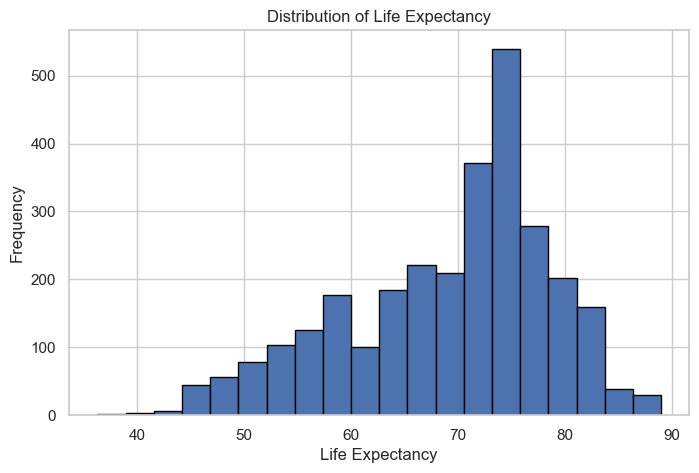

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df["Life expectancy"], bins=20, edgecolor='black')
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.title("Distribution of Life Expectancy")
plt.show()

From the histogram, we can observe that the Life Expectancy data is slightly left-skewed, mostly concentrated in the range of 70 to 75 years. The mean life expectancy is 69.3 years, and the median life expectancy is 71.7 years, with a maximum value of 89 years and a minimum of 44 years. The data has a standard deviation of 8.79, which indicates a moderate spread of data around the mean value.

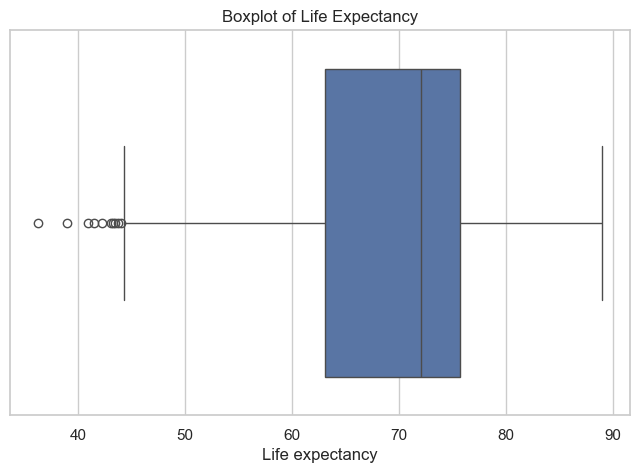

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Life expectancy"])
plt.title("Boxplot of Life Expectancy")
plt.show()

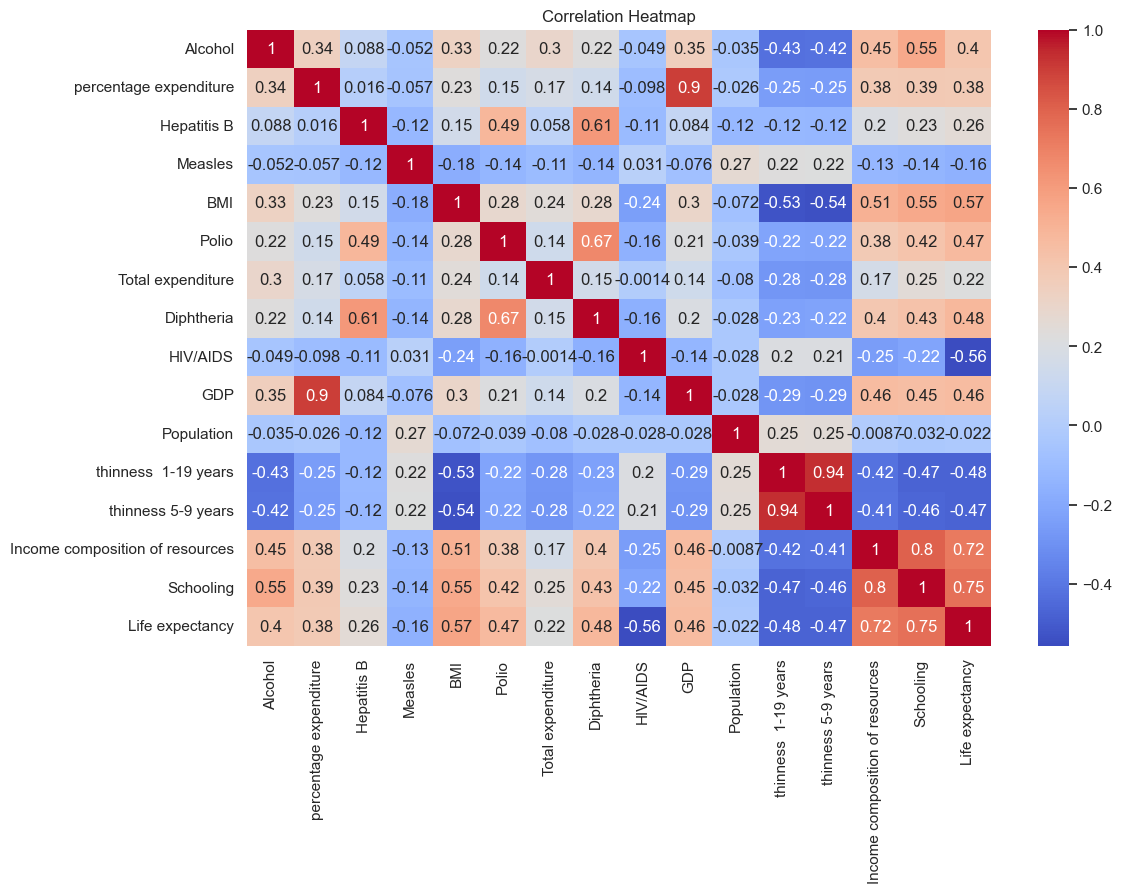

In [26]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [27]:
corr_target = corr["Life expectancy"].sort_values(ascending=False)

print(corr_target)

Life expectancy                    1.000000
Schooling                          0.751975
Income composition of resources    0.724776
BMI                                0.567694
Diphtheria                         0.479495
Polio                              0.465556
GDP                                0.461455
Alcohol                            0.404877
percentage expenditure             0.381864
Hepatitis B                        0.256762
Total expenditure                  0.218086
Population                        -0.021538
Measles                           -0.157586
thinness 5-9 years                -0.471584
thinness  1-19 years              -0.477183
HIV/AIDS                          -0.556556
Name: Life expectancy, dtype: float64


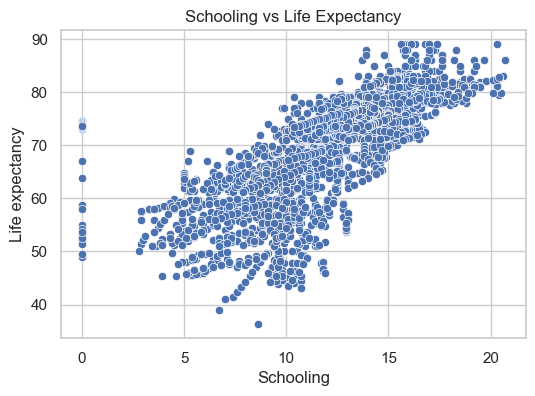

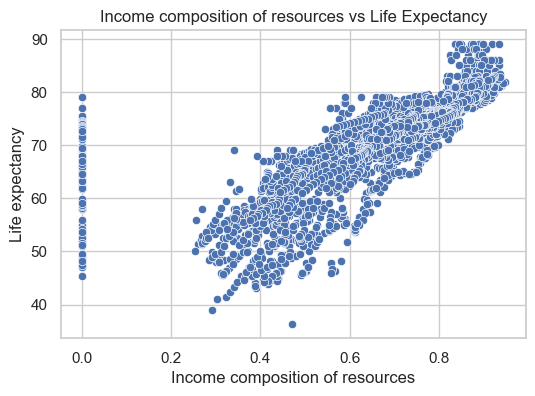

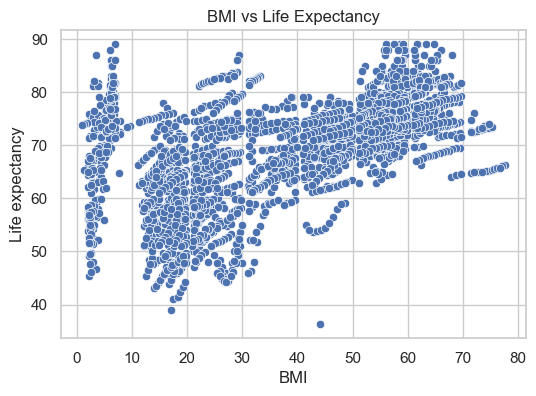

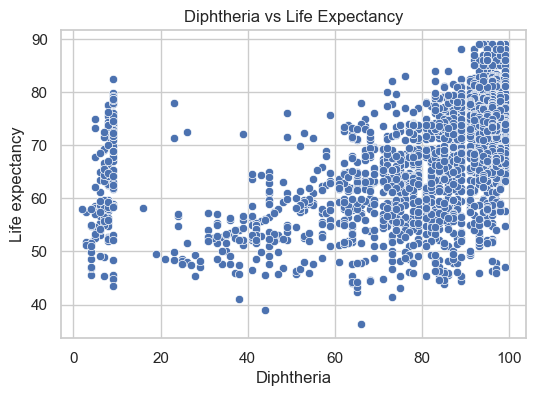

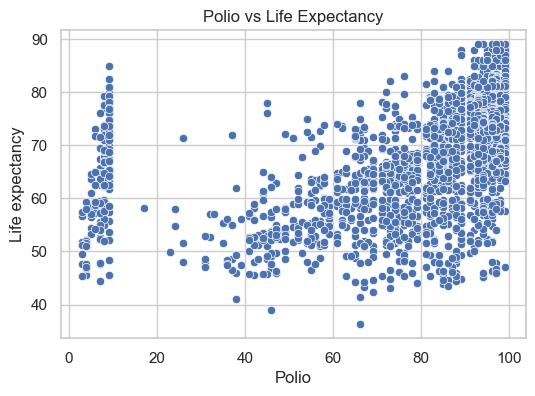

In [28]:
top_features = corr_target.index[1:6]

for feature in top_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[feature], y=df["Life expectancy"])
    plt.title(f"{feature} vs Life Expectancy")
    plt.show()

In [29]:
median_val = df["Life expectancy"].median()

df["target_binary"] = (df["Life expectancy"] >= median_val).astype(int)

df["target_binary"].value_counts()

target_binary
0    1472
1    1466
Name: count, dtype: int64

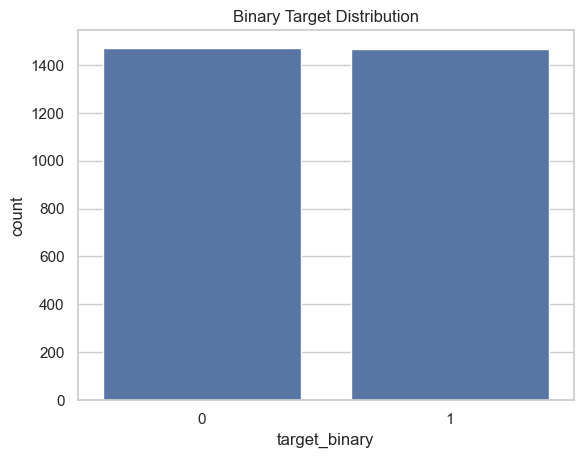

In [30]:
sns.countplot(x=df["target_binary"])
plt.title("Binary Target Distribution")
plt.show()

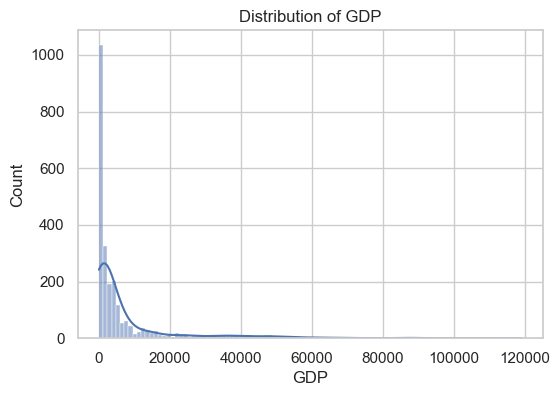

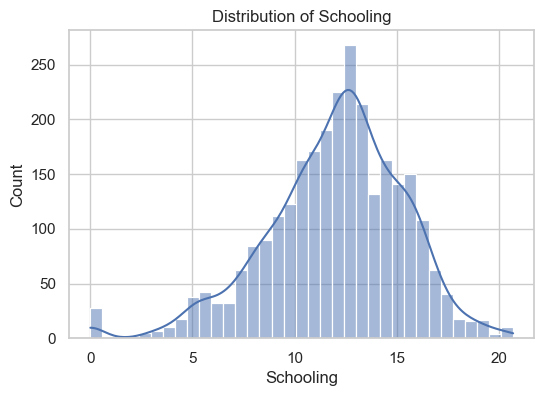

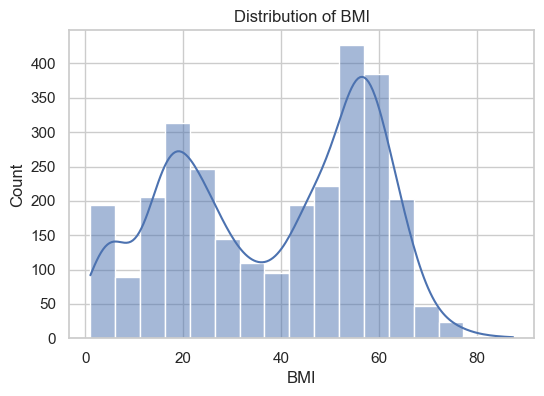

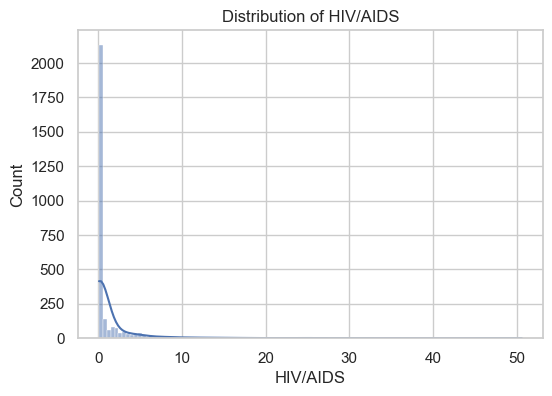

In [31]:
features = ["GDP", "Schooling", "BMI", "HIV/AIDS"]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[feature], kde=True)
    plt.title(f"Distribution of {feature}")
    plt.show()

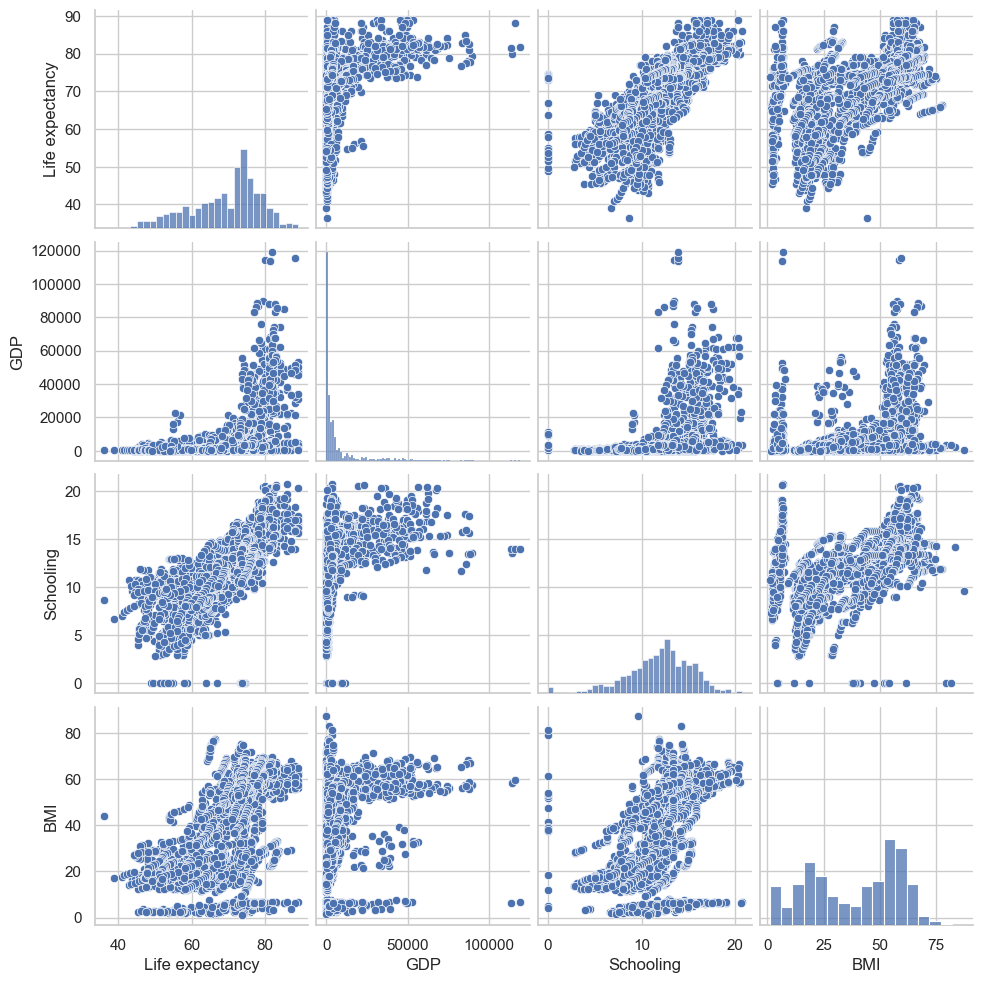

In [32]:
sns.pairplot(df[["Life expectancy", "GDP", "Schooling", "BMI"]])
plt.show()